In [7]:
import numpy as np
import tensorflow as tf
from data_generator import VideoDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# PATH
TEST_DIR = r"D:\DataScience\Deep Learning Project\Video_Classifier\data\processed\test"


In [ ]:
# LOAD MODEL
from tensorflow.keras.models import load_model
model = tf.keras.models.load_model(r"D:\DataScience\Deep Learning Project\Video_Classifier\best_model.h5")

In [ ]:
# GENERATOR
test_gen = VideoDataGenerator(TEST_DIR, batch_size=8, shuffle=False)

In [ ]:
# EVALUATION
print("\nEvaluating on Test Data...\n")

loss, accuracy = model.evaluate(test_gen)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


Evaluating on Test Data...



d:\DataScience\Deep Learning Project\Video_Classifier\venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


8/8 ━━━━━━━━━━━━━━━━━━━━ 65s 589ms/step - accuracy: 0.9138 - loss: 0.1538
Test Loss: 0.1538
Test Accuracy: 0.9138


In [ ]:
# PREDICTIONS
y_true = np.array(test_gen.labels)
y_pred_probs = model.predict(test_gen)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

8/8 ━━━━━━━━━━━━━━━━━━━━ 71s 5s/step 


In [ ]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Non-Violence", "Violence"]))


Classification Report:
              precision    recall  f1-score   support

Non-Violence       0.90      0.93      0.91        28
    Violence       0.93      0.90      0.92        30

    accuracy                           0.91        58
   macro avg       0.91      0.91      0.91        58
weighted avg       0.91      0.91      0.91        58



In [ ]:
# Confusion matrix
print("\nConfusion Matrix:")
cm=confusion_matrix(y_true, y_pred)
print(cm)


Confusion Matrix:
[[26  2]
 [ 3 27]]


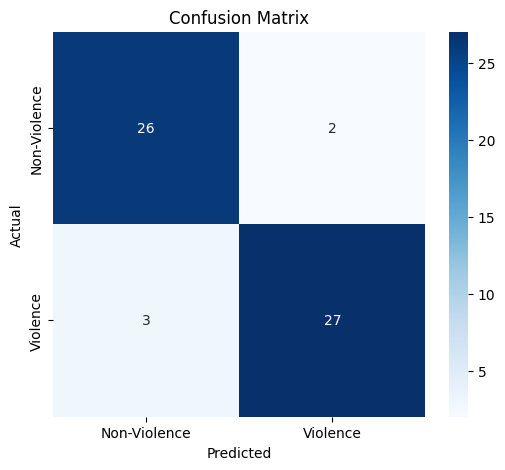

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Violence', 'Violence'],
            yticklabels=['Non-Violence', 'Violence'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()